In [21]:
import numpy as np
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow import keras
import warnings

warnings.filterwarnings("ignore")

In [6]:
linesapce = "="*60

In [5]:
# Dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [7]:
print(x_train.shape)
print(linesapce)
print(x_test.shape)
print(linesapce)
print(y_train.shape)
print(linesapce)
print(y_test.shape)
print(linesapce)

(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


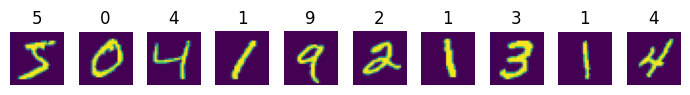

In [8]:
# Visualization:
fig, axs = plt.subplots(1,10, figsize=(7,7))

for i , ax in enumerate(axs):
  ax.imshow(x_train[i])
  ax.set_title(y_train[i])
  ax.axis("off")


plt.tight_layout()
plt.show()

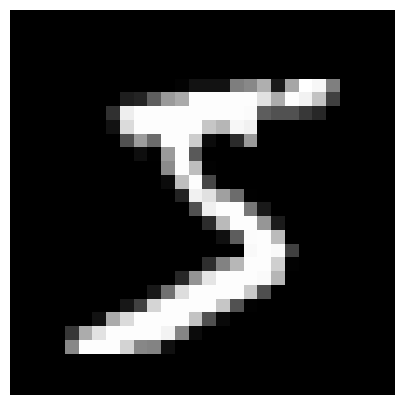

In [12]:
plt.figure(figsize=(5,5))
plt.imshow(x_train[0], cmap="grey")
plt.axis("off")
plt.show()

In [13]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 170,
        253, 253, 253, 253, 253, 225, 172, 253, 242, 195,  64,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  49, 238, 253, 253, 253, 253,
        253, 253, 253, 253, 251,  93,  82,  82,  56,  39,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  18, 219, 253, 253, 253, 253,
        253, 198, 182, 247, 241,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  80, 156, 107, 253, 253,
        205,  11,   0,  43, 154,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  14,   1, 154, 253,
         90,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 139, 253,
        190,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  11, 190,
        253,  70,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  35,
        241, 225, 160, 108,   1,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         81, 240, 253, 253, 119,  25,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  45, 186, 253, 253, 150,  27,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  16,  93, 252, 253, 187,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 249, 253, 249,  64,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  46, 130, 183, 253, 253, 207,   2,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  39,
        148, 229, 253, 253, 253, 250, 182,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  24, 114, 221,
        253, 253, 253, 253, 201,  78,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  23,  66, 213, 253, 253,
        253, 253, 198,  81,   2,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  18, 171, 219, 253, 253, 253, 253,
        195,  80,   9,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  55, 172, 226, 253, 253, 253, 253, 244, 133,
         11,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 136, 253, 25

In [16]:
int(y_train[0])

5

In [29]:
x_train[0].shape

(28, 28)

In [45]:
# Model Intialization:

model = keras.Sequential()


#Adding layers:
model.add(keras.layers.Flatten(input_shape=(28,28)))
model.add(keras.layers.Dense(100, activation="relu"))
model.add(keras.layers.Dense(200, activation="relu"))
model.add(keras.layers.Dense(200, activation="relu"))
model.add(keras.layers.Dense(100, activation="relu"))
model.add(keras.layers.Dense(10, activation="softmax"))


#Summary:
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 200)            │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,010 (625.04 KB)

 Trainable params: 160,010 (625.04 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
# Model Compilation
model.compile(
    optimizer="adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

# Fitting the model:
history = model.fit(x_train, y_train,
          epochs = 25,
          validation_split = 0.2,
          batch_size=32
          )

Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8705 - loss: 0.6537 - val_accuracy: 0.9342 - val_loss: 0.2317
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9429 - loss: 0.2007 - val_accuracy: 0.9406 - val_loss: 0.2121
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9545 - loss: 0.1555 - val_accuracy: 0.9527 - val_loss: 0.1755
Epoch 4/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9594 - loss: 0.1403 - val_accuracy: 0.9560 - val_loss: 0.1589
Epoch 5/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9662 - loss: 0.1185 - val_accuracy: 0.9564 - val_loss: 0.1664
Epoch 6/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9684 - loss: 0.1113 - val_accuracy: 0.9590 - val_loss: 0.1547
Epoch 7/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9735 - loss: 0.0970 - val_accuracy: 0.9636 - val_loss: 0.1454
Epoch 8/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9775 - loss: 0.0824 - 

In [47]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nTest Accuracy: {test_acc:.4f}")

313/313 - 2s - 5ms/step - accuracy: 0.9723 - loss: 0.1710

Test Accuracy: 0.9723


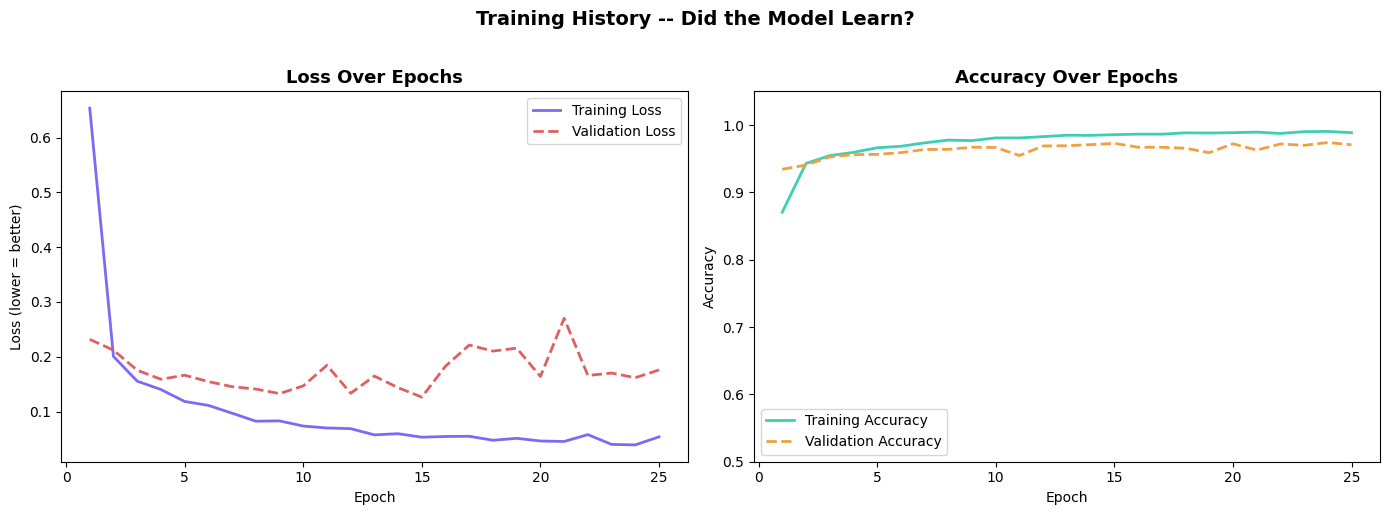

Final Training Accuracy   : 98.9%
Final Validation Accuracy : 97.1%

Gap between train/val is small -- healthy training!


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history.history['loss']) + 1)

# Loss curve
axes[0].plot(epochs_range, history.history['loss'],
             color="#7c6af7", linewidth=2, label="Training Loss")
axes[0].plot(epochs_range, history.history['val_loss'],
             color="#e06060", linewidth=2, linestyle="--", label="Validation Loss")
axes[0].set_title("Loss Over Epochs", fontweight="bold", fontsize=13)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss (lower = better)")
axes[0].legend()

# Accuracy curve
axes[1].plot(epochs_range, history.history['accuracy'],
             color="#3ecfb2", linewidth=2, label="Training Accuracy")
axes[1].plot(epochs_range, history.history['val_accuracy'],
             color="#f0a040", linewidth=2, linestyle="--", label="Validation Accuracy")
axes[1].set_title("Accuracy Over Epochs", fontweight="bold", fontsize=13)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.5, 1.05)
axes[1].legend()

plt.suptitle("Training History -- Did the Model Learn?",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

final_train = history.history['accuracy'][-1]
final_val   = history.history['val_accuracy'][-1]
print(f"Final Training Accuracy   : {final_train*100:.1f}%")
print(f"Final Validation Accuracy : {final_val*100:.1f}%")
print()
gap = abs(final_train - final_val)
if gap < 0.05:
    print("Gap between train/val is small -- healthy training!")
else:
    print(f"Gap is {gap*100:.1f}% -- watch for overfitting.")